In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
pd.set_option('display.max_columns',50)

In [2]:
df = pd.read_csv("/kaggle/input/datasets/reddyrohith/gridlockround2/jan to may police violation_anonymized791b166.csv")

In [3]:
df.head()

,id,latitude,longitude,location,vehicle_number,vehicle_type,description,violation_type,offence_code,created_datetime,closed_datetime,modified_datetime,device_id,created_by_id,center_code,police_station,data_sent_to_scita,junction_name,action_taken_timestamp,data_sent_to_scita_timestamp,updated_vehicle_number,updated_vehicle_type,validation_status,validation_timestamp
0,FKID000000,12.925557,77.618665,"18th Main Road, Block 2, Koramangala, Bengalur...",FKN00GL0000,CAR,NaN,"[""WRONG PARKING"",""PARKING NEAR ROAD CROSSING""]","[112,104]",2023-11-20 00:28:46+00,NaN,2023-11-28 04:48:04.582978+00,FKDEV00000,FKUSR00000,9.0,Madiwala,True,No Junction,NaN,NaN,FKN00GL0000,MAXI-CAB,approved,2023-11-30 03:08:24.818+00
1,FKID000001,12.905463,77.700778,"Sarjapura Main Road, The Grove, Janatha Colony...",FKN00GL0001,CAR,NaN,"[""NO PARKING""]",[113],2023-11-24 22:46:46+00,NaN,2023-11-24 23:00:24.115257+00,FKDEV00001,FKUSR00001,82.0,Bellandur,False,No Junction,NaN,NaN,NaN,NaN,NaN,NaN
2,FKID000002,12.925449,77.618504,"Koramangala 2nd Block, Kormangala West, Bengal...",FKN00GL0002,CAR,NaN,"[""WRONG PARKING"",""PARKING IN A MAIN ROAD""]","[112,107]",2023-11-20 00:27:46+00,NaN,2023-11-28 04:47:02.33776+00,FKDEV00000,FKUSR00000,9.0,Madiwala,True,No Junction,NaN,NaN,FKN00GL0002,MAXI-CAB,approved,2023-11-30 03:08:56.998+00
3,FKID000003,12.956521,77.518618,"6th Cross Road, Manasa Layout, Nagarbhavi, Ben...",FKN00GL0003,SCOOTER,NaN,"[""NO PARKING""]",[113],2023-11-16 06:47:46+00,NaN,2023-11-18 04:46:57.216868+00,FKDEV00002,FKUSR00002,26.0,Byatarayanapura,True,No Junction,NaN,NaN,FKN00GL0003,SCOOTER,approved,2023-11-18 23:35:12.428+00
4,FKID000004,12.977767,77.580545,"Kalidasa Road, Gandhinagar, Nehru Nagar, Benga...",FKN00GL0004,TANKER,NaN,"[""NO PARKING""]",[113],2023-11-22 04:56:46+00,NaN,2023-11-28 02:44:50.46737+00,FKDEV00003,FKUSR00003,3.0,Upparpet,True,BTP044 - Sagar Theatre Junction,NaN,NaN,FKN00GL0004,TANKER,approved,2023-11-30 03:11:32.796+00


In [4]:
df.shape

(298450, 24)

In [5]:
df.isnull().sum()

id                                   0
latitude                             0
longitude                            0
location                          3041
vehicle_number                       0
vehicle_type                         0
description                     298450
violation_type                       0
offence_code                         0
created_datetime                     0
closed_datetime                 298450
modified_datetime                    0
device_id                            0
created_by_id                        5
center_code                      11260
police_station                       5
data_sent_to_scita                   0
junction_name                        5
action_taken_timestamp          298450
data_sent_to_scita_timestamp    256289
updated_vehicle_number          125254
updated_vehicle_type            125254
validation_status               125254
validation_timestamp            125254
dtype: int64

In [6]:
df = df.drop(columns=["description","closed_datetime","action_taken_timestamp",
                     "data_sent_to_scita_timestamp","validation_status","validation_timestamp"])

In [7]:
df["vehicle_type"] = df["updated_vehicle_type"].fillna(df["vehicle_type"])
df.drop(columns=["updated_vehicle_type"], inplace=True)

In [8]:
df.head(1)

,id,latitude,longitude,location,vehicle_number,vehicle_type,violation_type,offence_code,created_datetime,modified_datetime,device_id,created_by_id,center_code,police_station,data_sent_to_scita,junction_name,updated_vehicle_number
0,FKID000000,12.925557,77.618665,"18th Main Road, Block 2, Koramangala, Bengalur...",FKN00GL0000,MAXI-CAB,"[""WRONG PARKING"",""PARKING NEAR ROAD CROSSING""]","[112,104]",2023-11-20 00:28:46+00,2023-11-28 04:48:04.582978+00,FKDEV00000,FKUSR00000,9.0,Madiwala,True,No Junction,FKN00GL0000


In [9]:
df.isnull().sum()

id                             0
latitude                       0
longitude                      0
location                    3041
vehicle_number                 0
vehicle_type                   0
violation_type                 0
offence_code                   0
created_datetime               0
modified_datetime              0
device_id                      0
created_by_id                  5
center_code                11260
police_station                 5
data_sent_to_scita             0
junction_name                  5
updated_vehicle_number    125254
dtype: int64

In [10]:
temp = df["updated_vehicle_number"].fillna(df["vehicle_number"])

different = temp != df["vehicle_number"]

print("Number of rows where updated value differs from vehicle_number:",
      different.sum())

Number of rows where updated value differs from vehicle_number: 1774


In [11]:
df["vehicle_number"] = df["updated_vehicle_number"].fillna(df["vehicle_number"])
df.drop(columns=["updated_vehicle_number"], inplace=True)

In [12]:
df.isnull().sum()

id                        0
latitude                  0
longitude                 0
location               3041
vehicle_number            0
vehicle_type              0
violation_type            0
offence_code              0
created_datetime          0
modified_datetime         0
device_id                 0
created_by_id             5
center_code           11260
police_station            5
data_sent_to_scita        0
junction_name             5
dtype: int64

In [13]:
df[df["police_station"].isna()]

,id,latitude,longitude,location,vehicle_number,vehicle_type,violation_type,offence_code,created_datetime,modified_datetime,device_id,created_by_id,center_code,police_station,data_sent_to_scita,junction_name
78294,FKID078294,12.980154,77.602585,NaN,FKN00GL67834,CAR,"[""NO PARKING""]",[113],2024-03-20 03:30:21.022782+00,2024-03-20 03:30:21.023225+00,FKDEV01424,NaN,NaN,NaN,False,NaN
130925,FKID130925,12.980154,77.602585,NaN,FKN00GL67834,CAR,"[""NO PARKING""]",[113],2024-03-20 03:30:24.526372+00,2024-03-20 03:30:24.526849+00,FKDEV01424,NaN,NaN,NaN,False,NaN
202797,FKID202797,12.964844,77.584040,NaN,FKN00GL165623,TEMPO,"[""WRONG PARKING"",""DEFECTIVE NUMBER PLATE""]","[112,116]",2023-11-26 00:35:55.977404+00,2023-11-26 00:35:55.977818+00,FKDEV01913,NaN,NaN,NaN,True,NaN
205656,FKID205656,12.992108,77.552681,NaN,FKN00GL145766,LGV,"[""WRONG PARKING""]",[112],2023-12-19 22:48:32.680242+00,2023-12-19 22:48:32.680616+00,FKDEV00077,NaN,NaN,NaN,True,NaN
277561,FKID277561,12.964844,77.584040,NaN,FKN00GL165623,TEMPO,"[""WRONG PARKING""]",[112],2023-11-26 00:35:29.493726+00,2023-11-26 00:35:29.494157+00,FKDEV01913,NaN,NaN,NaN,True,NaN


In [14]:
df[(df["device_id"]=="FKDEV01424") & (df["created_by_id"]=="FKUSR01353")]

,id,latitude,longitude,location,vehicle_number,vehicle_type,violation_type,offence_code,created_datetime,modified_datetime,device_id,created_by_id,center_code,police_station,data_sent_to_scita,junction_name
18440,FKID018440,12.979358,77.602191,"Cubbon Road, Shivaji Nagar Intersection Juncti...",FKN00GL17337,CAR,"[""NO PARKING""]",[113],2024-01-12 23:01:46+00,2024-01-12 23:35:33.413679+00,FKDEV01424,FKUSR01353,16.0,Shivajinagar,True,BTP211 - Central Street Junction
36700,FKID036700,12.982333,77.610610,"Kamaraj Road, Sri Nagamma Devi Circle, Sivanch...",FKN00GL33317,MOTOR CYCLE,"[""NO PARKING""]",[113],2024-04-01 04:28:46+00,2024-04-01 04:52:51.805368+00,FKDEV01424,FKUSR01353,16.0,Shivajinagar,True,No Junction
36725,FKID036725,12.982333,77.610610,"Kamaraj Road, Sri Nagamma Devi Circle, Sivanch...",FKN00GL7134,PASSENGER AUTO,"[""NO PARKING""]",[113],2024-04-01 04:28:46+00,2024-04-01 04:52:52.820778+00,FKDEV01424,FKUSR01353,16.0,Shivajinagar,True,No Junction
36763,FKID036763,12.982333,77.610610,"Kamaraj Road, Sri Nagamma Devi Circle, Sivanch...",FKN00GL33374,PASSENGER AUTO,"[""NO PARKING""]",[113],2024-04-01 04:29:46+00,2024-04-01 04:52:53.593541+00,FKDEV01424,FKUSR01353,16.0,Shivajinagar,True,No Junction
37491,FKID037491,12.981779,77.610366,"Kamaraj Road, Sri Nagamma Devi Circle, Sivanch...",FKN00GL7048,PASSENGER AUTO,"[""DEFECTIVE NUMBER PLATE"",""NO PARKING""]","[116,113]",2024-04-01 04:25:46+00,2024-04-01 04:27:13.182534+00,FKDEV01424,FKUSR01353,16.0,Shivajinagar,True,BTP051 - Safina Plaza Junction
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295044,FKID295044,12.979577,77.607040,"Main Guard Cross Road, Tasker Town, Shivaji Na...",FKN00GL230742,CAR,"[""NO PARKING""]",[113],2023-11-29 03:31:46+00,2023-11-29 05:10:55.095307+00,FKDEV01424,FKUSR01353,16.0,Shivajinagar,True,BTP051 - Safina Plaza Junction
295045,FKID295045,12.979604,77.607008,"Main Guard Cross Road, Tasker Town, Shivaji Na...",FKN00GL68549,CAR,"[""NO PARKING""]",[113],2023-11-29 03:31:46+00,2023-11-29 05:10:53.771801+00,FKDEV01424,FKUSR01353,16.0,Shivajinagar,True,BTP051 - Safina Plaza Junction
295046,FKID295046,12.979604,77.607008,"Main Guard Cross Road, Tasker Town, Shivaji Na...",FKN00GL230743,CAR,"[""NO PARKING""]",[113],2023-11-29 03:30:46+00,2023-11-29 05:10:51.316783+00,FKDEV01424,FKUSR01353,16.0,Shivajinagar,True,BTP051 - Safina Plaza Junction
295047,FKID295047,12.979577,77.607040,"Main Guard Cross Road, Tasker Town, Shivaji Na...",FKN00GL108780,CAR,"[""NO PARKING""]",[113],2023-11-29 03:31:46+00,2023-11-29 05:10:56.455548+00,FKDEV01424,FKUSR01353,16.0,Shivajinagar,True,BTP051 - Safina Plaza Junction


In [15]:
df[(df["device_id"]=="FKDEV01424") & (df["created_by_id"]!="FKUSR01353")]

,id,latitude,longitude,location,vehicle_number,vehicle_type,violation_type,offence_code,created_datetime,modified_datetime,device_id,created_by_id,center_code,police_station,data_sent_to_scita,junction_name
78294,FKID078294,12.980154,77.602585,NaN,FKN00GL67834,CAR,"[""NO PARKING""]",[113],2024-03-20 03:30:21.022782+00,2024-03-20 03:30:21.023225+00,FKDEV01424,NaN,NaN,NaN,False,NaN
130925,FKID130925,12.980154,77.602585,NaN,FKN00GL67834,CAR,"[""NO PARKING""]",[113],2024-03-20 03:30:24.526372+00,2024-03-20 03:30:24.526849+00,FKDEV01424,NaN,NaN,NaN,False,NaN


In [16]:
df["created_by_id"] = df["created_by_id"].fillna("FKUSR01353")

In [17]:
df[df["police_station"].isna()]

,id,latitude,longitude,location,vehicle_number,vehicle_type,violation_type,offence_code,created_datetime,modified_datetime,device_id,created_by_id,center_code,police_station,data_sent_to_scita,junction_name
78294,FKID078294,12.980154,77.602585,NaN,FKN00GL67834,CAR,"[""NO PARKING""]",[113],2024-03-20 03:30:21.022782+00,2024-03-20 03:30:21.023225+00,FKDEV01424,FKUSR01353,NaN,NaN,False,NaN
130925,FKID130925,12.980154,77.602585,NaN,FKN00GL67834,CAR,"[""NO PARKING""]",[113],2024-03-20 03:30:24.526372+00,2024-03-20 03:30:24.526849+00,FKDEV01424,FKUSR01353,NaN,NaN,False,NaN
202797,FKID202797,12.964844,77.584040,NaN,FKN00GL165623,TEMPO,"[""WRONG PARKING"",""DEFECTIVE NUMBER PLATE""]","[112,116]",2023-11-26 00:35:55.977404+00,2023-11-26 00:35:55.977818+00,FKDEV01913,FKUSR01353,NaN,NaN,True,NaN
205656,FKID205656,12.992108,77.552681,NaN,FKN00GL145766,LGV,"[""WRONG PARKING""]",[112],2023-12-19 22:48:32.680242+00,2023-12-19 22:48:32.680616+00,FKDEV00077,FKUSR01353,NaN,NaN,True,NaN
277561,FKID277561,12.964844,77.584040,NaN,FKN00GL165623,TEMPO,"[""WRONG PARKING""]",[112],2023-11-26 00:35:29.493726+00,2023-11-26 00:35:29.494157+00,FKDEV01913,FKUSR01353,NaN,NaN,True,NaN


In [18]:
df[(df["created_by_id"]=="FKUSR01353") & (df["police_station"]=="Shivajinagar")]

,id,latitude,longitude,location,vehicle_number,vehicle_type,violation_type,offence_code,created_datetime,modified_datetime,device_id,created_by_id,center_code,police_station,data_sent_to_scita,junction_name
18440,FKID018440,12.979358,77.602191,"Cubbon Road, Shivaji Nagar Intersection Juncti...",FKN00GL17337,CAR,"[""NO PARKING""]",[113],2024-01-12 23:01:46+00,2024-01-12 23:35:33.413679+00,FKDEV01424,FKUSR01353,16.0,Shivajinagar,True,BTP211 - Central Street Junction
36700,FKID036700,12.982333,77.610610,"Kamaraj Road, Sri Nagamma Devi Circle, Sivanch...",FKN00GL33317,MOTOR CYCLE,"[""NO PARKING""]",[113],2024-04-01 04:28:46+00,2024-04-01 04:52:51.805368+00,FKDEV01424,FKUSR01353,16.0,Shivajinagar,True,No Junction
36725,FKID036725,12.982333,77.610610,"Kamaraj Road, Sri Nagamma Devi Circle, Sivanch...",FKN00GL7134,PASSENGER AUTO,"[""NO PARKING""]",[113],2024-04-01 04:28:46+00,2024-04-01 04:52:52.820778+00,FKDEV01424,FKUSR01353,16.0,Shivajinagar,True,No Junction
36763,FKID036763,12.982333,77.610610,"Kamaraj Road, Sri Nagamma Devi Circle, Sivanch...",FKN00GL33374,PASSENGER AUTO,"[""NO PARKING""]",[113],2024-04-01 04:29:46+00,2024-04-01 04:52:53.593541+00,FKDEV01424,FKUSR01353,16.0,Shivajinagar,True,No Junction
37491,FKID037491,12.981779,77.610366,"Kamaraj Road, Sri Nagamma Devi Circle, Sivanch...",FKN00GL7048,PASSENGER AUTO,"[""DEFECTIVE NUMBER PLATE"",""NO PARKING""]","[116,113]",2024-04-01 04:25:46+00,2024-04-01 04:27:13.182534+00,FKDEV01424,FKUSR01353,16.0,Shivajinagar,True,BTP051 - Safina Plaza Junction
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295044,FKID295044,12.979577,77.607040,"Main Guard Cross Road, Tasker Town, Shivaji Na...",FKN00GL230742,CAR,"[""NO PARKING""]",[113],2023-11-29 03:31:46+00,2023-11-29 05:10:55.095307+00,FKDEV01424,FKUSR01353,16.0,Shivajinagar,True,BTP051 - Safina Plaza Junction
295045,FKID295045,12.979604,77.607008,"Main Guard Cross Road, Tasker Town, Shivaji Na...",FKN00GL68549,CAR,"[""NO PARKING""]",[113],2023-11-29 03:31:46+00,2023-11-29 05:10:53.771801+00,FKDEV01424,FKUSR01353,16.0,Shivajinagar,True,BTP051 - Safina Plaza Junction
295046,FKID295046,12.979604,77.607008,"Main Guard Cross Road, Tasker Town, Shivaji Na...",FKN00GL230743,CAR,"[""NO PARKING""]",[113],2023-11-29 03:30:46+00,2023-11-29 05:10:51.316783+00,FKDEV01424,FKUSR01353,16.0,Shivajinagar,True,BTP051 - Safina Plaza Junction
295047,FKID295047,12.979577,77.607040,"Main Guard Cross Road, Tasker Town, Shivaji Na...",FKN00GL108780,CAR,"[""NO PARKING""]",[113],2023-11-29 03:31:46+00,2023-11-29 05:10:56.455548+00,FKDEV01424,FKUSR01353,16.0,Shivajinagar,True,BTP051 - Safina Plaza Junction


In [19]:
df[(df["created_by_id"]=="FKUSR01353") & (df["police_station"]!="Shivajinagar")]

,id,latitude,longitude,location,vehicle_number,vehicle_type,violation_type,offence_code,created_datetime,modified_datetime,device_id,created_by_id,center_code,police_station,data_sent_to_scita,junction_name
78294,FKID078294,12.980154,77.602585,NaN,FKN00GL67834,CAR,"[""NO PARKING""]",[113],2024-03-20 03:30:21.022782+00,2024-03-20 03:30:21.023225+00,FKDEV01424,FKUSR01353,NaN,NaN,False,NaN
130925,FKID130925,12.980154,77.602585,NaN,FKN00GL67834,CAR,"[""NO PARKING""]",[113],2024-03-20 03:30:24.526372+00,2024-03-20 03:30:24.526849+00,FKDEV01424,FKUSR01353,NaN,NaN,False,NaN
202797,FKID202797,12.964844,77.584040,NaN,FKN00GL165623,TEMPO,"[""WRONG PARKING"",""DEFECTIVE NUMBER PLATE""]","[112,116]",2023-11-26 00:35:55.977404+00,2023-11-26 00:35:55.977818+00,FKDEV01913,FKUSR01353,NaN,NaN,True,NaN
205656,FKID205656,12.992108,77.552681,NaN,FKN00GL145766,LGV,"[""WRONG PARKING""]",[112],2023-12-19 22:48:32.680242+00,2023-12-19 22:48:32.680616+00,FKDEV00077,FKUSR01353,NaN,NaN,True,NaN
277561,FKID277561,12.964844,77.584040,NaN,FKN00GL165623,TEMPO,"[""WRONG PARKING""]",[112],2023-11-26 00:35:29.493726+00,2023-11-26 00:35:29.494157+00,FKDEV01913,FKUSR01353,NaN,NaN,True,NaN


In [20]:
df["police_station"] = df["police_station"].fillna("Shivajinagar")

In [21]:
df.isnull().sum()

id                        0
latitude                  0
longitude                 0
location               3041
vehicle_number            0
vehicle_type              0
violation_type            0
offence_code              0
created_datetime          0
modified_datetime         0
device_id                 0
created_by_id             0
center_code           11260
police_station            0
data_sent_to_scita        0
junction_name             5
dtype: int64

In [22]:
df[df["location"].isna()]

,id,latitude,longitude,location,vehicle_number,vehicle_type,violation_type,offence_code,created_datetime,modified_datetime,device_id,created_by_id,center_code,police_station,data_sent_to_scita,junction_name
122,FKID000122,12.953837,77.640934,NaN,FKN00GL0114,MAXI-CAB,"[""NO PARKING""]",[113],2023-12-20 02:39:46+00,2023-12-22 03:07:25.202206+00,FKDEV00054,FKUSR00054,17.0,Halasur,False,No Junction
446,FKID000446,12.952523,77.699824,NaN,FKN00GL0438,TEMPO,"[""PARKING IN A MAIN ROAD"",""WRONG PARKING""]","[107,112]",2024-03-15 00:12:46+00,2024-03-15 00:13:54.050487+00,FKDEV00168,FKUSR00168,13.0,HAL Old Airport,True,No Junction
564,FKID000564,12.982001,77.532375,NaN,FKN00GL0556,CAR,"[""NO PARKING""]",[113],2023-11-23 00:20:46+00,2023-11-25 20:47:54.787657+00,FKDEV00205,FKUSR00205,33.0,Kamakshipalya,True,No Junction
587,FKID000587,12.917330,77.573428,NaN,FKN00GL0578,PASSENGER AUTO,"[""NO PARKING"",""DEFECTIVE NUMBER PLATE""]","[113,116]",2023-12-19 06:18:46+00,2023-12-19 06:39:22.372198+00,FKDEV00210,FKUSR00210,23.0,Banashankari,False,"BTP115 - Sahasra Hospital, Jayanagar"
650,FKID000650,12.822340,77.686374,NaN,FKN00GL0643,CAR,"[""PARKING IN A MAIN ROAD"",""WRONG PARKING""]","[107,112]",2023-12-22 02:05:46+00,2023-12-22 03:57:47.580582+00,FKDEV00222,FKUSR00222,38.0,Electronic City,False,No Junction
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297336,FKID297336,13.005535,77.568325,NaN,FKN00GL232322,MAXI-CAB,"[""NO PARKING""]",[113],2023-11-30 07:31:46+00,2023-11-30 20:45:42.610174+00,FKDEV00060,FKUSR00060,19.0,Malleshwaram,True,No Junction
297892,FKID297892,12.928551,77.581135,NaN,FKN00GL85390,CAR,"[""NO PARKING""]",[113],2023-11-28 05:09:46+00,2023-11-28 05:17:09.637891+00,FKDEV00199,FKUSR00199,25.0,Jayanagara,True,"BTP189 - New Diagonal Road, Jayanagar"
297996,FKID297996,12.980094,77.555611,NaN,FKN00GL232744,SCOOTER,"[""WRONG PARKING""]",[112],2023-11-27 05:47:46+00,2023-11-27 05:49:49.170151+00,FKDEV00955,FKUSR00916,29.0,Magadi Road,True,"BTP062 - Basava Mantapa, Dr. Rajkumar Road"
298181,FKID298181,12.988250,77.577065,NaN,FKN00GL5996,CAR,"[""PARKING IN A MAIN ROAD"",""WRONG PARKING""]","[107,112]",2024-03-02 04:42:46+00,2024-04-14 01:16:54.132194+00,FKDEV00916,FKUSR00880,87.0,Sheshadripuram,False,BTP054 - Shivananda Circle


In [23]:
df[(df["center_code"]==17) & (df["police_station"]!="Halasur")]

,id,latitude,longitude,location,vehicle_number,vehicle_type,violation_type,offence_code,created_datetime,modified_datetime,device_id,created_by_id,center_code,police_station,data_sent_to_scita,junction_name


In [24]:
station_center_counts = df.groupby("police_station")["center_code"].nunique()

multiple_centers = station_center_counts[station_center_counts > 1]

print(multiple_centers)

Series([], Name: center_code, dtype: int64)


In [25]:
station_to_center = (
    df[df["center_code"].notna()]
    .groupby("police_station")["center_code"]
    .first()
)

print("Police stations with known center codes:", len(station_to_center))

Police stations with known center codes: 52


In [26]:
station_to_center = (
    df[df["center_code"].notna()]
    .groupby("police_station")["center_code"]
    .first()
)

In [27]:
station_to_center

police_station
Adugodi                    5.0
Ashok Nagar                8.0
Banashankari              23.0
Banaswadi                 34.0
Basavanagudi               7.0
Bellandur                 82.0
Byatarayanapura           26.0
Chamarajpet               27.0
Chikkabanavara            86.0
Chikkajala                40.0
City Market               28.0
Cubbon Park                2.0
Devanahalli Airport       41.0
Electronic City           38.0
HAL Old Airport           13.0
HSR Layout                45.0
Halasur                   17.0
Halasuru Gate             12.0
Hebbala                   18.0
Hennuru                   81.0
High ground               11.0
Hulimavu                  44.0
J.P. Nagar                88.0
Jalahalli                 43.0
Jayanagara                25.0
Jeevanbheemanagar          4.0
Jnanabharathi             85.0
K.G. Halli                46.0
K.R. Pura                 15.0
K.S. Layout               35.0
Kamakshipalya             33.0
Kengeri                 

In [28]:
df["center_code"] = df["center_code"].fillna(
    df["police_station"].map(station_to_center)
)

In [29]:
df.isnull().sum()

id                        0
latitude                  0
longitude                 0
location               3041
vehicle_number            0
vehicle_type              0
violation_type            0
offence_code              0
created_datetime          0
modified_datetime         0
device_id                 0
created_by_id             0
center_code           11255
police_station            0
data_sent_to_scita        0
junction_name             5
dtype: int64

In [30]:
print("Total police stations:", df["police_station"].nunique())
print("Police stations with missing center_code rows:",
      df[df["center_code"].isna()]["police_station"].nunique())

Total police stations: 54
Police stations with missing center_code rows: 2


In [31]:
missing_stations = df.loc[df["center_code"].isna(), "police_station"].unique()

print(missing_stations)

['Kodigehalli' 'No Police Station']


In [32]:
max_code = int(df["center_code"].max())
new_codes = {
    "Kodigehalli": max_code + 1,
    "No Police Station": max_code + 2
}

df["center_code"] = df["center_code"].fillna(
    df["police_station"].map(new_codes)
)

In [33]:
df.isnull().sum()

id                       0
latitude                 0
longitude                0
location              3041
vehicle_number           0
vehicle_type             0
violation_type           0
offence_code             0
created_datetime         0
modified_datetime        0
device_id                0
created_by_id            0
center_code              0
police_station           0
data_sent_to_scita       0
junction_name            5
dtype: int64

In [34]:
df.head()

,id,latitude,longitude,location,vehicle_number,vehicle_type,violation_type,offence_code,created_datetime,modified_datetime,device_id,created_by_id,center_code,police_station,data_sent_to_scita,junction_name
0,FKID000000,12.925557,77.618665,"18th Main Road, Block 2, Koramangala, Bengalur...",FKN00GL0000,MAXI-CAB,"[""WRONG PARKING"",""PARKING NEAR ROAD CROSSING""]","[112,104]",2023-11-20 00:28:46+00,2023-11-28 04:48:04.582978+00,FKDEV00000,FKUSR00000,9.0,Madiwala,True,No Junction
1,FKID000001,12.905463,77.700778,"Sarjapura Main Road, The Grove, Janatha Colony...",FKN00GL0001,CAR,"[""NO PARKING""]",[113],2023-11-24 22:46:46+00,2023-11-24 23:00:24.115257+00,FKDEV00001,FKUSR00001,82.0,Bellandur,False,No Junction
2,FKID000002,12.925449,77.618504,"Koramangala 2nd Block, Kormangala West, Bengal...",FKN00GL0002,MAXI-CAB,"[""WRONG PARKING"",""PARKING IN A MAIN ROAD""]","[112,107]",2023-11-20 00:27:46+00,2023-11-28 04:47:02.33776+00,FKDEV00000,FKUSR00000,9.0,Madiwala,True,No Junction
3,FKID000003,12.956521,77.518618,"6th Cross Road, Manasa Layout, Nagarbhavi, Ben...",FKN00GL0003,SCOOTER,"[""NO PARKING""]",[113],2023-11-16 06:47:46+00,2023-11-18 04:46:57.216868+00,FKDEV00002,FKUSR00002,26.0,Byatarayanapura,True,No Junction
4,FKID000004,12.977767,77.580545,"Kalidasa Road, Gandhinagar, Nehru Nagar, Benga...",FKN00GL0004,TANKER,"[""NO PARKING""]",[113],2023-11-22 04:56:46+00,2023-11-28 02:44:50.46737+00,FKDEV00003,FKUSR00003,3.0,Upparpet,True,BTP044 - Sagar Theatre Junction


In [35]:
print(df.iloc[0][ "location"])

18th Main Road, Block 2, Koramangala, Bengaluru, Karnataka. Pin-560068 (India)


In [36]:
print(df.iloc[2][ "location"])

Koramangala 2nd Block, Kormangala West, Bengaluru South City Corporation, Bengaluru, Bangalore South, Bengaluru Urban, Karnataka, 560034, India


In [37]:
total = df.groupby('police_station').size()
nulls = df[df['location'].isna()].groupby('police_station').size()
nulls[nulls == total]

Series([], dtype: int64)

In [38]:
df[df['location'].isna()]['police_station'].unique()

array(['Halasur', 'HAL Old Airport', 'Kamakshipalya', 'Banashankari',
       'Electronic City', 'Adugodi', 'Upparpet', 'Ashok Nagar',
       'Magadi Road', 'Rajajinagar', 'K.R. Pura', 'R.T. Nagar',
       'Malleshwaram', 'Hennuru', 'J.P. Nagar', 'Wilson Garden',
       'Shivajinagar', 'No Police Station', 'Cubbon Park', 'Madiwala',
       'City Market', 'Banaswadi', 'High ground', 'Byatarayanapura',
       'Jalahalli', 'Vijayanagara', 'Jayanagara', 'Yeshwanthpura',
       'Bellandur', 'K.S. Layout', 'Mahadevapura', 'Sheshadripuram',
       'V.V.Puram (C.Pet)', 'Halasuru Gate', 'HSR Layout', 'Basavanagudi',
       'Pulikeshinagar(F.Town)', 'Kodigehalli', 'Chamarajpet', 'Hebbala',
       'Hulimavu', 'Chikkajala', 'Thalagattapura', 'Whitefield',
       'Mico Layout', 'Jeevanbheemanagar', 'Sadashivanagar', 'Kengeri',
       'Yelahanka', 'Peenya', 'K.G. Halli', 'Devanahalli Airport',
       'Jnanabharathi', 'Chikkabanavara'], dtype=object)

In [39]:
df.head()

,id,latitude,longitude,location,vehicle_number,vehicle_type,violation_type,offence_code,created_datetime,modified_datetime,device_id,created_by_id,center_code,police_station,data_sent_to_scita,junction_name
0,FKID000000,12.925557,77.618665,"18th Main Road, Block 2, Koramangala, Bengalur...",FKN00GL0000,MAXI-CAB,"[""WRONG PARKING"",""PARKING NEAR ROAD CROSSING""]","[112,104]",2023-11-20 00:28:46+00,2023-11-28 04:48:04.582978+00,FKDEV00000,FKUSR00000,9.0,Madiwala,True,No Junction
1,FKID000001,12.905463,77.700778,"Sarjapura Main Road, The Grove, Janatha Colony...",FKN00GL0001,CAR,"[""NO PARKING""]",[113],2023-11-24 22:46:46+00,2023-11-24 23:00:24.115257+00,FKDEV00001,FKUSR00001,82.0,Bellandur,False,No Junction
2,FKID000002,12.925449,77.618504,"Koramangala 2nd Block, Kormangala West, Bengal...",FKN00GL0002,MAXI-CAB,"[""WRONG PARKING"",""PARKING IN A MAIN ROAD""]","[112,107]",2023-11-20 00:27:46+00,2023-11-28 04:47:02.33776+00,FKDEV00000,FKUSR00000,9.0,Madiwala,True,No Junction
3,FKID000003,12.956521,77.518618,"6th Cross Road, Manasa Layout, Nagarbhavi, Ben...",FKN00GL0003,SCOOTER,"[""NO PARKING""]",[113],2023-11-16 06:47:46+00,2023-11-18 04:46:57.216868+00,FKDEV00002,FKUSR00002,26.0,Byatarayanapura,True,No Junction
4,FKID000004,12.977767,77.580545,"Kalidasa Road, Gandhinagar, Nehru Nagar, Benga...",FKN00GL0004,TANKER,"[""NO PARKING""]",[113],2023-11-22 04:56:46+00,2023-11-28 02:44:50.46737+00,FKDEV00003,FKUSR00003,3.0,Upparpet,True,BTP044 - Sagar Theatre Junction


In [40]:
df['created_datetime'] = pd.to_datetime(df['created_datetime'], format='ISO8601', utc=True)
df['modified_datetime'] = pd.to_datetime(df['modified_datetime'], format='ISO8601', utc=True)

# Response time in minutes
df['response_time_mins'] = (df['modified_datetime'] - df['created_datetime']).dt.total_seconds() / 60

print(df['response_time_mins'].describe())
print(f"\nNegative values: {(df['response_time_mins'] < 0).sum()}")
print(f"Zero values: {(df['response_time_mins'] == 0).sum()}")
print(f"Under 1 hour: {(df['response_time_mins'] < 60).sum()}")
print(f"Under 1 day: {(df['response_time_mins'] < 1440).sum()}")
print(f"Over 1 day: {(df['response_time_mins'] >= 1440).sum()}")

count    298450.000000
mean        510.873277
std        2463.136199
min       -4318.555995
25%           4.938175
50%          15.896499
75%          71.164404
max      161183.000694
Name: response_time_mins, dtype: float64

Negative values: 314
Zero values: 0
Under 1 hour: 218281
Under 1 day: 274972
Over 1 day: 23478


In [41]:
df = df.drop(columns=['modified_datetime', 'response_time_mins'])

df['hour'] = df['created_datetime'].dt.hour
df['day_of_week'] = df['created_datetime'].dt.day_name()
df['month'] = df['created_datetime'].dt.month
df['is_weekend'] = df['created_datetime'].dt.dayofweek >= 5

In [42]:
df.head()

,id,latitude,longitude,location,vehicle_number,vehicle_type,violation_type,offence_code,created_datetime,device_id,created_by_id,center_code,police_station,data_sent_to_scita,junction_name,hour,day_of_week,month,is_weekend
0,FKID000000,12.925557,77.618665,"18th Main Road, Block 2, Koramangala, Bengalur...",FKN00GL0000,MAXI-CAB,"[""WRONG PARKING"",""PARKING NEAR ROAD CROSSING""]","[112,104]",2023-11-20 00:28:46+00:00,FKDEV00000,FKUSR00000,9.0,Madiwala,True,No Junction,0,Monday,11,False
1,FKID000001,12.905463,77.700778,"Sarjapura Main Road, The Grove, Janatha Colony...",FKN00GL0001,CAR,"[""NO PARKING""]",[113],2023-11-24 22:46:46+00:00,FKDEV00001,FKUSR00001,82.0,Bellandur,False,No Junction,22,Friday,11,False
2,FKID000002,12.925449,77.618504,"Koramangala 2nd Block, Kormangala West, Bengal...",FKN00GL0002,MAXI-CAB,"[""WRONG PARKING"",""PARKING IN A MAIN ROAD""]","[112,107]",2023-11-20 00:27:46+00:00,FKDEV00000,FKUSR00000,9.0,Madiwala,True,No Junction,0,Monday,11,False
3,FKID000003,12.956521,77.518618,"6th Cross Road, Manasa Layout, Nagarbhavi, Ben...",FKN00GL0003,SCOOTER,"[""NO PARKING""]",[113],2023-11-16 06:47:46+00:00,FKDEV00002,FKUSR00002,26.0,Byatarayanapura,True,No Junction,6,Thursday,11,False
4,FKID000004,12.977767,77.580545,"Kalidasa Road, Gandhinagar, Nehru Nagar, Benga...",FKN00GL0004,TANKER,"[""NO PARKING""]",[113],2023-11-22 04:56:46+00:00,FKDEV00003,FKUSR00003,3.0,Upparpet,True,BTP044 - Sagar Theatre Junction,4,Wednesday,11,False


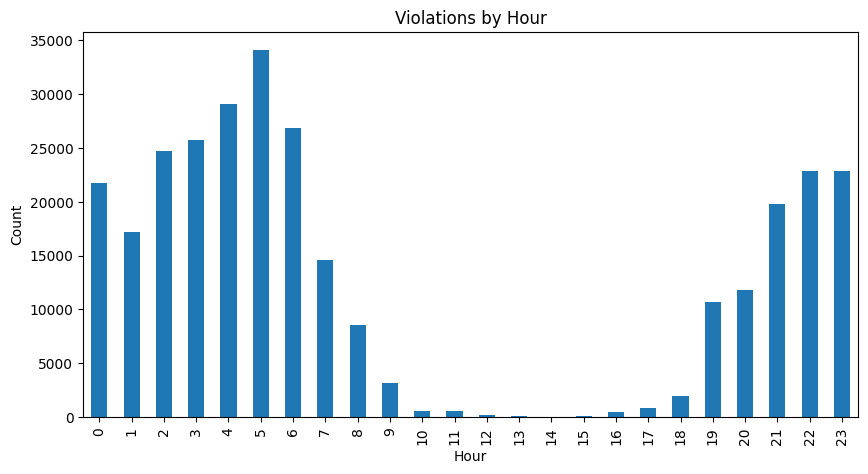

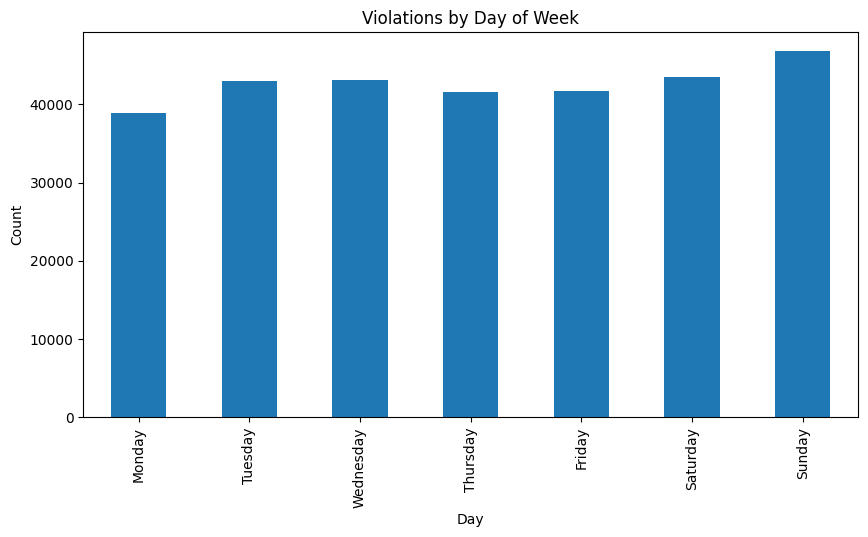

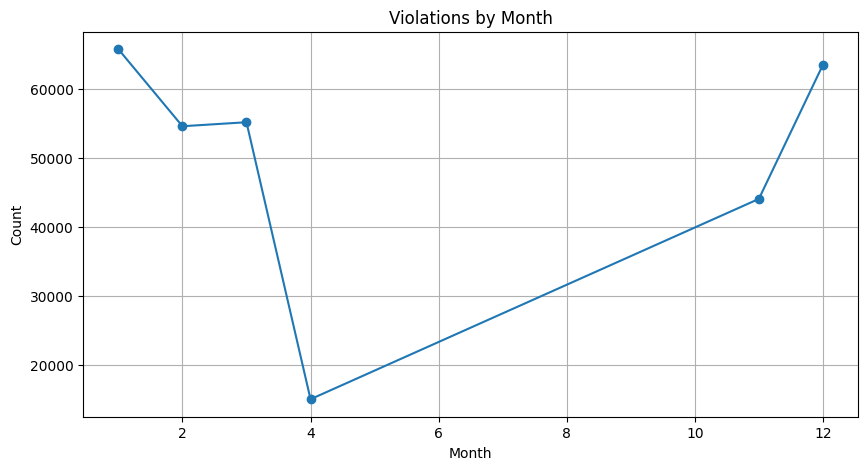

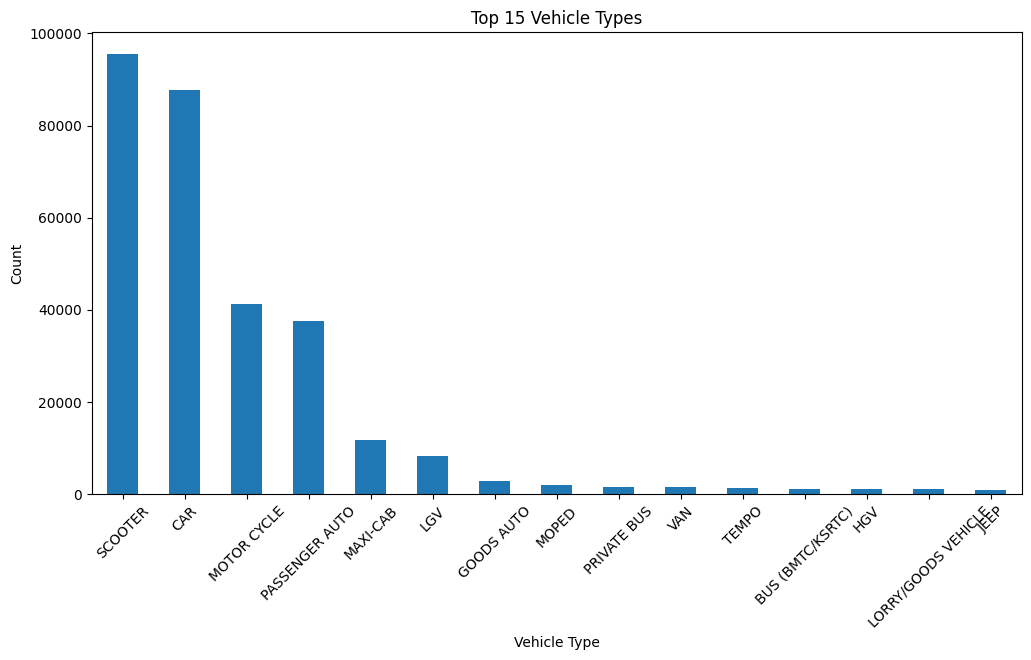

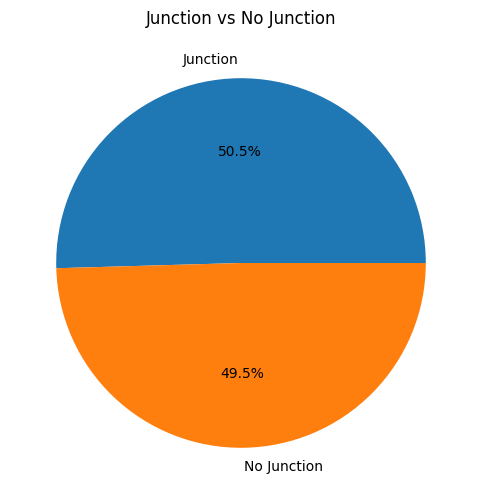

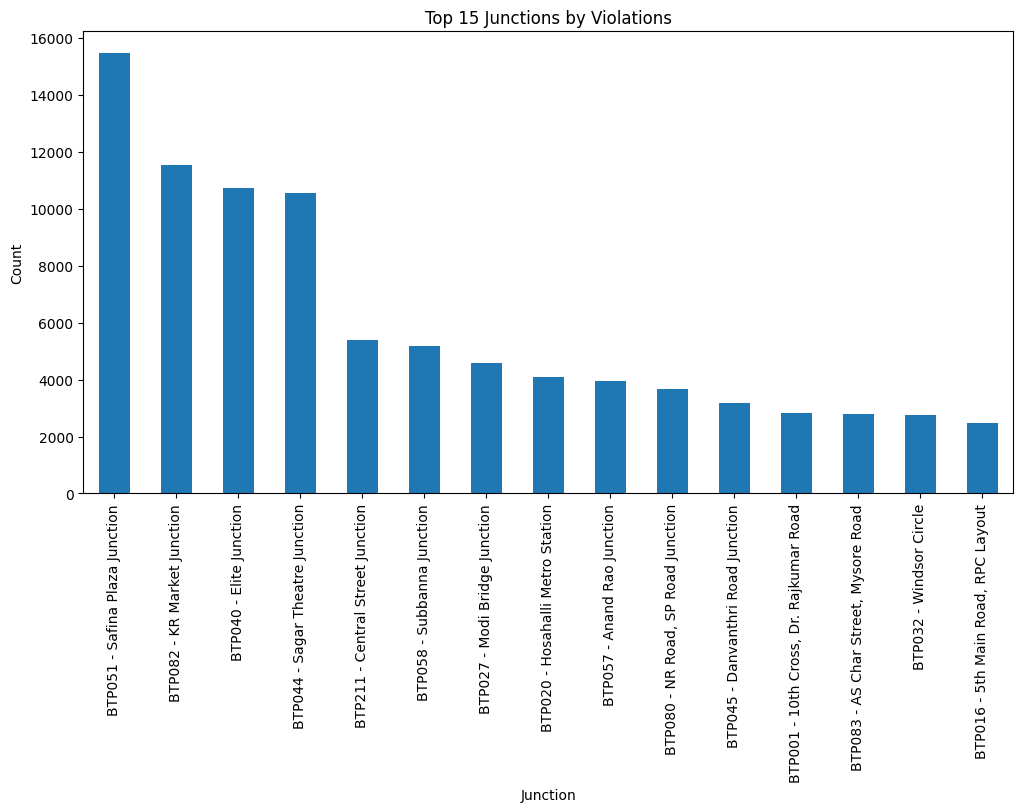

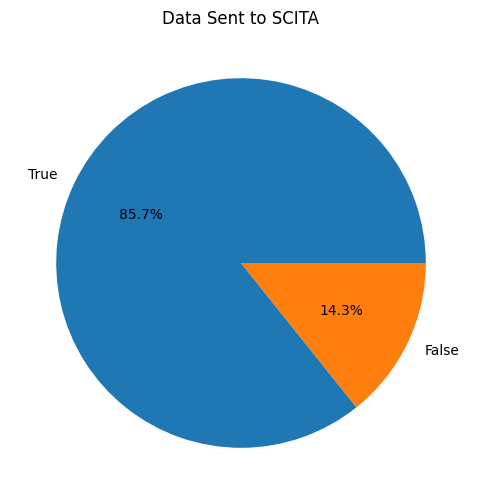

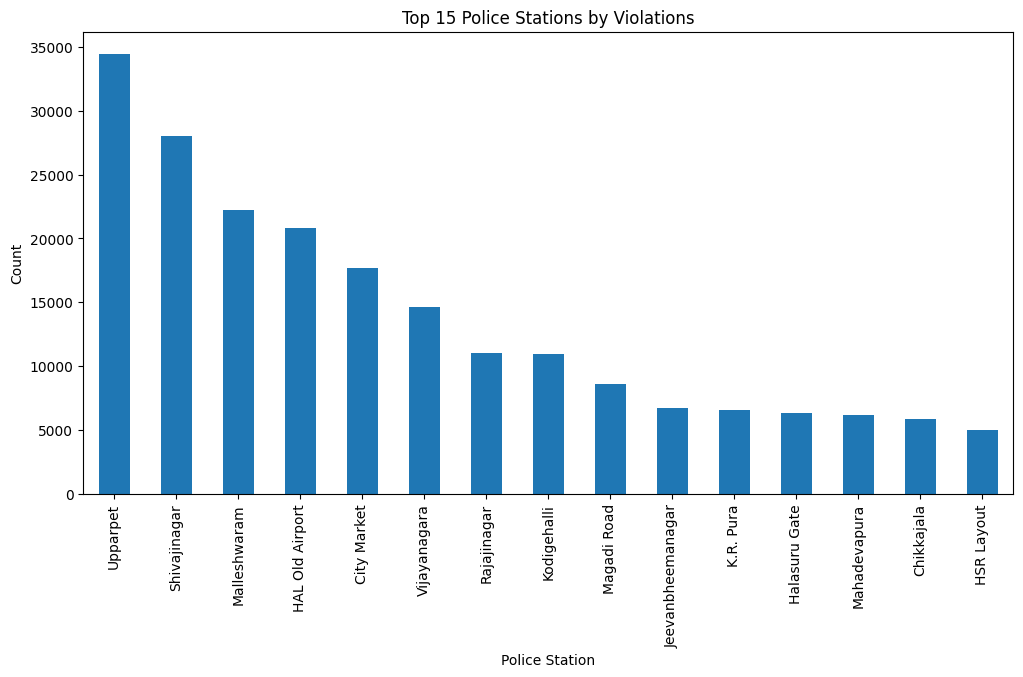

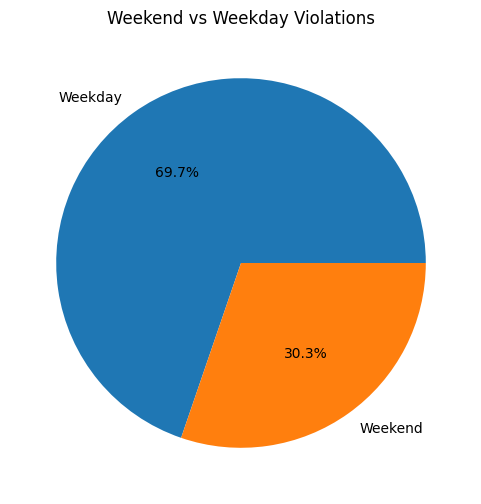

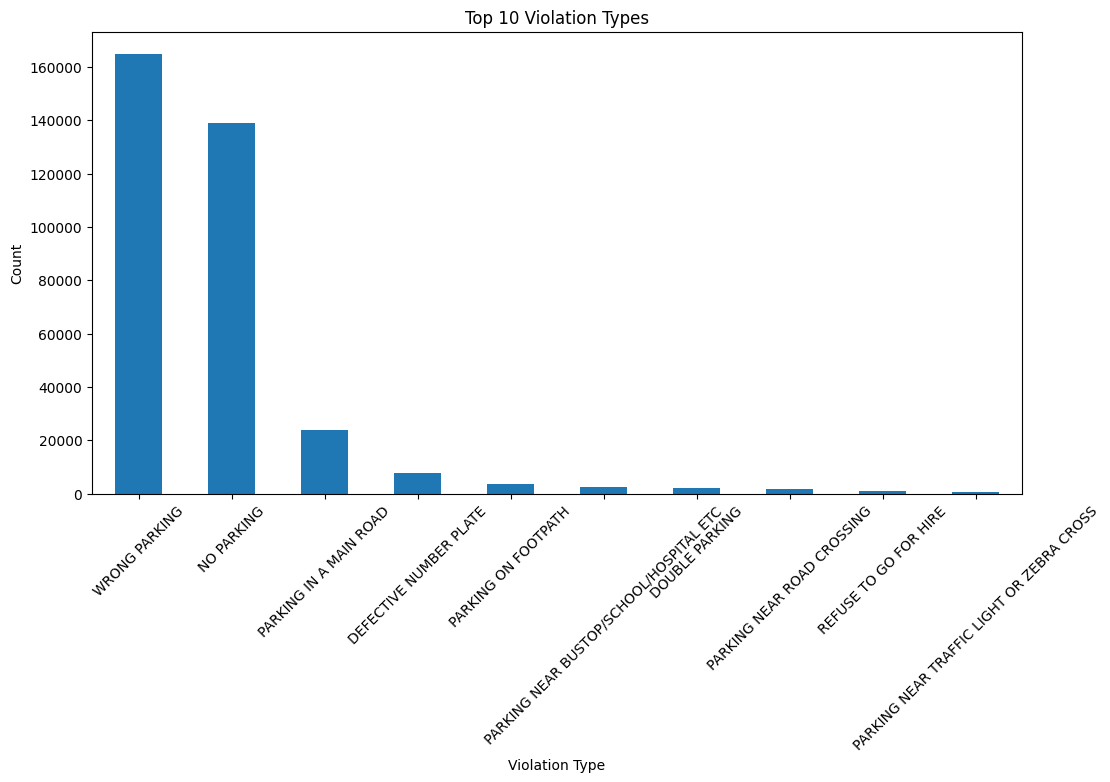

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import ast

# ==========================
# 1. Violations by Hour
# ==========================
hour_counts = df['hour'].value_counts().sort_index()

plt.figure(figsize=(10,5))
hour_counts.plot(kind='bar')
plt.title('Violations by Hour')
plt.xlabel('Hour')
plt.ylabel('Count')
plt.show()

# ==========================
# 2. Violations by Day
# ==========================
day_order = ['Monday','Tuesday','Wednesday','Thursday',
             'Friday','Saturday','Sunday']

day_counts = df['day_of_week'].value_counts().reindex(day_order)

plt.figure(figsize=(10,5))
day_counts.plot(kind='bar')
plt.title('Violations by Day of Week')
plt.xlabel('Day')
plt.ylabel('Count')
plt.show()

# ==========================
# 3. Violations by Month
# ==========================
month_counts = df['month'].value_counts().sort_index()

plt.figure(figsize=(10,5))
month_counts.plot(kind='line', marker='o')
plt.title('Violations by Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.grid(True)
plt.show()

# ==========================
# 4. Vehicle Type Distribution
# ==========================
vehicle_counts = df['vehicle_type'].value_counts().head(15)

plt.figure(figsize=(12,6))
vehicle_counts.plot(kind='bar')
plt.title('Top 15 Vehicle Types')
plt.xlabel('Vehicle Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# ==========================
# 5. Junction vs No Junction
# ==========================
junction_counts = (
    df['junction_name']
    .ne('No Junction')
    .map({True:'Junction', False:'No Junction'})
    .value_counts()
)

plt.figure(figsize=(6,6))
junction_counts.plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.title('Junction vs No Junction')
plt.show()

# ==========================
# 6. Top 15 Junctions
# ==========================
top_junctions = (
    df[df['junction_name'] != 'No Junction']
    ['junction_name']
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12,6))
top_junctions.plot(kind='bar')
plt.title('Top 15 Junctions by Violations')
plt.xlabel('Junction')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

# ==========================
# 7. Data Sent to SCITA
# ==========================
scita_counts = df['data_sent_to_scita'].value_counts()

plt.figure(figsize=(6,6))
scita_counts.plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.title('Data Sent to SCITA')
plt.show()

# ==========================
# 8. Top Police Stations
# ==========================
top_stations = df['police_station'].value_counts().head(15)

plt.figure(figsize=(12,6))
top_stations.plot(kind='bar')
plt.title('Top 15 Police Stations by Violations')
plt.xlabel('Police Station')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

# ==========================
# 9. Weekend vs Weekday
# ==========================
weekend_counts = (
    df['is_weekend']
    .map({True:'Weekend', False:'Weekday'})
    .value_counts()
)

plt.figure(figsize=(6,6))
weekend_counts.plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.title('Weekend vs Weekday Violations')
plt.show()

# ==========================
# 10. Violation Type Distribution
# ==========================
all_violations = []

for v in df['violation_type']:
    try:
        all_violations.extend(ast.literal_eval(v))
    except:
        pass

violation_counts = pd.Series(dict(Counter(all_violations))) \
                      .sort_values(ascending=False) \
                      .head(10)

plt.figure(figsize=(12,6))
violation_counts.plot(kind='bar')
plt.title('Top 10 Violation Types')
plt.xlabel('Violation Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [44]:
import ast

# Define parking-related violation types only
parking_violations = [
    'WRONG PARKING',
    'NO PARKING', 
    'PARKING IN A MAIN ROAD',
    'PARKING ON FOOTPATH',
    'PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC',
    'DOUBLE PARKING',
    'PARKING NEAR ROAD CROSSING',
    'PARKING NEAR TRAFFIC LIGHT OR ZEBRA CROSS'
]

# Parse violation_type and keep row only if it has at least one parking violation
def has_parking_violation(v):
    try:
        violations = ast.literal_eval(v)
        return any(viol in parking_violations for viol in violations)
    except:
        return False

parking_mask = df['violation_type'].apply(has_parking_violation)
df_parking = df[parking_mask].copy()

print(f"Original rows : {len(df):,}")
print(f"Parking rows  : {len(df_parking):,}")
print(f"Dropped rows  : {len(df) - len(df_parking):,}")
print(f"Kept          : {len(df_parking)/len(df)*100:.1f}%")

# See what got dropped
print("\n=== WHAT WAS FILTERED OUT ===")
all_violations = []
for v in df[~parking_mask]['violation_type']:
    try:
        all_violations.extend(ast.literal_eval(v))
    except:
        pass
from collections import Counter
print(Counter(all_violations).most_common(10))

Original rows : 298,450
Parking rows  : 298,450
Dropped rows  : 0
Kept          : 100.0%

=== WHAT WAS FILTERED OUT ===
[]


In [45]:
parking_violations = [
    'WRONG PARKING',
    'NO PARKING', 
    'PARKING IN A MAIN ROAD',
    'PARKING ON FOOTPATH',
    'PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC',
    'DOUBLE PARKING',
    'PARKING NEAR ROAD CROSSING',
    'PARKING NEAR TRAFFIC LIGHT OR ZEBRA CROSS'
]

def clean_violations(v):
    try:
        violations = ast.literal_eval(v)
        # Keep only parking-related ones
        parking_only = [x for x in violations if x in parking_violations]
        return parking_only if parking_only else violations  # fallback to original if empty
    except:
        return []

df['violation_type_clean'] = df['violation_type'].apply(clean_violations)

# Verify
print(df['violation_type_clean'].apply(len).describe())
print("\nSample:")
print(df['violation_type_clean'].head(10))

count    298450.000000
mean          1.133788
std           0.427161
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           8.000000
Name: violation_type_clean, dtype: float64

Sample:
0    [WRONG PARKING, PARKING NEAR ROAD CROSSING]
1                                   [NO PARKING]
2        [WRONG PARKING, PARKING IN A MAIN ROAD]
3                                   [NO PARKING]
4                                   [NO PARKING]
5                                   [NO PARKING]
6                                   [NO PARKING]
7                                [WRONG PARKING]
8                                   [NO PARKING]
9                                   [NO PARKING]
Name: violation_type_clean, dtype: object


In [46]:
df.head()

,id,latitude,longitude,location,vehicle_number,vehicle_type,violation_type,offence_code,created_datetime,device_id,created_by_id,center_code,police_station,data_sent_to_scita,junction_name,hour,day_of_week,month,is_weekend,violation_type_clean
0,FKID000000,12.925557,77.618665,"18th Main Road, Block 2, Koramangala, Bengalur...",FKN00GL0000,MAXI-CAB,"[""WRONG PARKING"",""PARKING NEAR ROAD CROSSING""]","[112,104]",2023-11-20 00:28:46+00:00,FKDEV00000,FKUSR00000,9.0,Madiwala,True,No Junction,0,Monday,11,False,"[WRONG PARKING, PARKING NEAR ROAD CROSSING]"
1,FKID000001,12.905463,77.700778,"Sarjapura Main Road, The Grove, Janatha Colony...",FKN00GL0001,CAR,"[""NO PARKING""]",[113],2023-11-24 22:46:46+00:00,FKDEV00001,FKUSR00001,82.0,Bellandur,False,No Junction,22,Friday,11,False,[NO PARKING]
2,FKID000002,12.925449,77.618504,"Koramangala 2nd Block, Kormangala West, Bengal...",FKN00GL0002,MAXI-CAB,"[""WRONG PARKING"",""PARKING IN A MAIN ROAD""]","[112,107]",2023-11-20 00:27:46+00:00,FKDEV00000,FKUSR00000,9.0,Madiwala,True,No Junction,0,Monday,11,False,"[WRONG PARKING, PARKING IN A MAIN ROAD]"
3,FKID000003,12.956521,77.518618,"6th Cross Road, Manasa Layout, Nagarbhavi, Ben...",FKN00GL0003,SCOOTER,"[""NO PARKING""]",[113],2023-11-16 06:47:46+00:00,FKDEV00002,FKUSR00002,26.0,Byatarayanapura,True,No Junction,6,Thursday,11,False,[NO PARKING]
4,FKID000004,12.977767,77.580545,"Kalidasa Road, Gandhinagar, Nehru Nagar, Benga...",FKN00GL0004,TANKER,"[""NO PARKING""]",[113],2023-11-22 04:56:46+00:00,FKDEV00003,FKUSR00003,3.0,Upparpet,True,BTP044 - Sagar Theatre Junction,4,Wednesday,11,False,[NO PARKING]


In [47]:
df[df["id"] != df["vehicle_number"]].shape

(298450, 20)

In [48]:
df[df["device_id"] != df["created_by_id"]].shape

(298450, 20)

In [49]:
df[df["device_id"].str.contains("FKDEV", na=False)].shape

(298450, 20)

In [50]:
df["device_id"] = df["device_id"].str.replace("FKDEV", "", regex=False)

In [51]:
df[df["created_by_id"].str.contains("FKUSR", na=False)].shape

(298450, 20)

In [52]:
df["created_by_id"] = df["created_by_id"].str.replace("FKUSR", "", regex=False)

In [53]:
print(df[df["id"].str.contains("FKID00", na=False)].shape)
print(df[df["vehicle_number"].str.contains("FKN00GL", na=False)].shape)

(10000, 20)
(298450, 20)


In [54]:
df["id"] = df["id"].str.replace("FKID", "", regex=False)
df["vehicle_number"] = df["vehicle_number"].str.replace("FKN00GL", "", regex=False)

In [55]:
df[df["id"] != df["vehicle_number"]]

,id,latitude,longitude,location,vehicle_number,vehicle_type,violation_type,offence_code,created_datetime,device_id,created_by_id,center_code,police_station,data_sent_to_scita,junction_name,hour,day_of_week,month,is_weekend,violation_type_clean
0,000000,12.925557,77.618665,"18th Main Road, Block 2, Koramangala, Bengalur...",0000,MAXI-CAB,"[""WRONG PARKING"",""PARKING NEAR ROAD CROSSING""]","[112,104]",2023-11-20 00:28:46+00:00,00000,00000,9.0,Madiwala,True,No Junction,0,Monday,11,False,"[WRONG PARKING, PARKING NEAR ROAD CROSSING]"
1,000001,12.905463,77.700778,"Sarjapura Main Road, The Grove, Janatha Colony...",0001,CAR,"[""NO PARKING""]",[113],2023-11-24 22:46:46+00:00,00001,00001,82.0,Bellandur,False,No Junction,22,Friday,11,False,[NO PARKING]
2,000002,12.925449,77.618504,"Koramangala 2nd Block, Kormangala West, Bengal...",0002,MAXI-CAB,"[""WRONG PARKING"",""PARKING IN A MAIN ROAD""]","[112,107]",2023-11-20 00:27:46+00:00,00000,00000,9.0,Madiwala,True,No Junction,0,Monday,11,False,"[WRONG PARKING, PARKING IN A MAIN ROAD]"
3,000003,12.956521,77.518618,"6th Cross Road, Manasa Layout, Nagarbhavi, Ben...",0003,SCOOTER,"[""NO PARKING""]",[113],2023-11-16 06:47:46+00:00,00002,00002,26.0,Byatarayanapura,True,No Junction,6,Thursday,11,False,[NO PARKING]
4,000004,12.977767,77.580545,"Kalidasa Road, Gandhinagar, Nehru Nagar, Benga...",0004,TANKER,"[""NO PARKING""]",[113],2023-11-22 04:56:46+00:00,00003,00003,3.0,Upparpet,True,BTP044 - Sagar Theatre Junction,4,Wednesday,11,False,[NO PARKING]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298445,298445,13.041997,77.613122,"MBT Road, Govind Pura, Nagavara, Bengaluru, Ka...",233057,VAN,"[""WRONG PARKING""]",[112],2023-12-19 04:12:46+00:00,01640,01541,46.0,K.G. Halli,True,No Junction,4,Tuesday,12,False,[WRONG PARKING]
298446,298446,12.977301,77.575638,"Subedar Chatram Road, RK Puram, Gandhi Nagar, ...",233058,PASSENGER AUTO,"[""WRONG PARKING""]",[112],2023-11-28 07:59:46+00:00,00093,00094,3.0,Upparpet,True,BTP040 - Elite Junction,7,Tuesday,11,False,[WRONG PARKING]
298447,298447,12.964256,77.577127,"KR Market Bus Terminus, BGS Flyover, Dharmaray...",233059,MOTOR CYCLE,"[""WRONG PARKING""]",[112],2023-11-19 20:12:46+00:00,00392,00388,28.0,City Market,False,BTP082 - KR Market Junction,20,Sunday,11,True,[WRONG PARKING]
298448,298448,12.907177,77.695918,"Sarjapura Main Road, Doddakannelli Circle, Dod...",233060,MAXI-CAB,"[""NO PARKING""]",[113],2023-11-24 22:46:46+00:00,00001,00001,82.0,Bellandur,False,No Junction,22,Friday,11,False,[NO PARKING]


In [56]:
df[df["device_id"] != df["created_by_id"]]

,id,latitude,longitude,location,vehicle_number,vehicle_type,violation_type,offence_code,created_datetime,device_id,created_by_id,center_code,police_station,data_sent_to_scita,junction_name,hour,day_of_week,month,is_weekend,violation_type_clean
222,000222,13.008197,77.694125,"MBT Road, Devasandra Junction, KR Puram, Benga...",0214,SCOOTER,"[""NO PARKING""]",[113],2023-11-30 18:58:46+00:00,00008,00093,15.0,K.R. Pura,True,No Junction,18,Thursday,11,False,[NO PARKING]
223,000223,12.976240,77.574724,"Major T Ramachandrappa Road, Elite Junction, G...",0215,MAXI-CAB,"[""WRONG PARKING""]",[112],2023-11-30 19:36:46+00:00,00093,00094,3.0,Upparpet,True,BTP045 - Danvanthri Road Junction,19,Thursday,11,False,[WRONG PARKING]
224,000224,13.008192,77.694486,"MBT Road, Devasandra Junction, KR Puram, Benga...",0216,VAN,"[""NO PARKING""]",[113],2023-11-30 18:58:46+00:00,00008,00093,15.0,K.R. Pura,True,No Junction,18,Thursday,11,False,[NO PARKING]
225,000225,12.964923,77.538664,"Sri Sankasta Hara Ganapati Temple Road, RPC La...",0217,SCOOTER,"[""WRONG PARKING""]",[112],2023-11-25 07:17:46+00:00,00094,00095,30.0,Vijayanagara,False,"BTP016 - 5th Main Road, RPC Layout",7,Saturday,11,True,[WRONG PARKING]
226,000226,12.977578,77.570093,"Railway Station Road, Majestic Circle, Majesti...",0218,PASSENGER AUTO,"[""NO PARKING"",""DEFECTIVE NUMBER PLATE""]","[113,116]",2023-11-30 19:17:46+00:00,00095,00096,27.0,Chamarajpet,True,BTP048 - Shanthala Junction,19,Thursday,11,False,[NO PARKING]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298442,298442,12.978064,77.580447,"1st Main Road, Jakkarayana Kere, Gandhi Nagar,...",233055,CAR,"[""WRONG PARKING""]",[112],2023-11-17 05:23:46+00:00,00382,00379,3.0,Upparpet,True,BTP058 - Subbanna Junction,5,Friday,11,False,[WRONG PARKING]
298443,298443,12.975184,77.588467,"Cubbon Park Road, Gandhi Nagar 2, Gandhi Nagar...",233056,SCOOTER,"[""NO PARKING""]",[113],2023-11-20 01:27:46+00:00,00298,00297,2.0,Cubbon Park,False,BTP037 - KR Circle,1,Monday,11,False,[NO PARKING]
298445,298445,13.041997,77.613122,"MBT Road, Govind Pura, Nagavara, Bengaluru, Ka...",233057,VAN,"[""WRONG PARKING""]",[112],2023-12-19 04:12:46+00:00,01640,01541,46.0,K.G. Halli,True,No Junction,4,Tuesday,12,False,[WRONG PARKING]
298446,298446,12.977301,77.575638,"Subedar Chatram Road, RK Puram, Gandhi Nagar, ...",233058,PASSENGER AUTO,"[""WRONG PARKING""]",[112],2023-11-28 07:59:46+00:00,00093,00094,3.0,Upparpet,True,BTP040 - Elite Junction,7,Tuesday,11,False,[WRONG PARKING]


In [57]:
df.isnull().sum()

id                         0
latitude                   0
longitude                  0
location                3041
vehicle_number             0
vehicle_type               0
violation_type             0
offence_code               0
created_datetime           0
device_id                  0
created_by_id              0
center_code                0
police_station             0
data_sent_to_scita         0
junction_name              5
hour                       0
day_of_week                0
month                      0
is_weekend                 0
violation_type_clean       0
dtype: int64

In [58]:
df.to_csv("data.csv",index=False)

In [59]:
df.head()

,id,latitude,longitude,location,vehicle_number,vehicle_type,violation_type,offence_code,created_datetime,device_id,created_by_id,center_code,police_station,data_sent_to_scita,junction_name,hour,day_of_week,month,is_weekend,violation_type_clean
0,000000,12.925557,77.618665,"18th Main Road, Block 2, Koramangala, Bengalur...",0000,MAXI-CAB,"[""WRONG PARKING"",""PARKING NEAR ROAD CROSSING""]","[112,104]",2023-11-20 00:28:46+00:00,00000,00000,9.0,Madiwala,True,No Junction,0,Monday,11,False,"[WRONG PARKING, PARKING NEAR ROAD CROSSING]"
1,000001,12.905463,77.700778,"Sarjapura Main Road, The Grove, Janatha Colony...",0001,CAR,"[""NO PARKING""]",[113],2023-11-24 22:46:46+00:00,00001,00001,82.0,Bellandur,False,No Junction,22,Friday,11,False,[NO PARKING]
2,000002,12.925449,77.618504,"Koramangala 2nd Block, Kormangala West, Bengal...",0002,MAXI-CAB,"[""WRONG PARKING"",""PARKING IN A MAIN ROAD""]","[112,107]",2023-11-20 00:27:46+00:00,00000,00000,9.0,Madiwala,True,No Junction,0,Monday,11,False,"[WRONG PARKING, PARKING IN A MAIN ROAD]"
3,000003,12.956521,77.518618,"6th Cross Road, Manasa Layout, Nagarbhavi, Ben...",0003,SCOOTER,"[""NO PARKING""]",[113],2023-11-16 06:47:46+00:00,00002,00002,26.0,Byatarayanapura,True,No Junction,6,Thursday,11,False,[NO PARKING]
4,000004,12.977767,77.580545,"Kalidasa Road, Gandhinagar, Nehru Nagar, Benga...",0004,TANKER,"[""NO PARKING""]",[113],2023-11-22 04:56:46+00:00,00003,00003,3.0,Upparpet,True,BTP044 - Sagar Theatre Junction,4,Wednesday,11,False,[NO PARKING]
